In [13]:
import pandas as pd

df = pd.read_csv("diabetes (1).csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [15]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


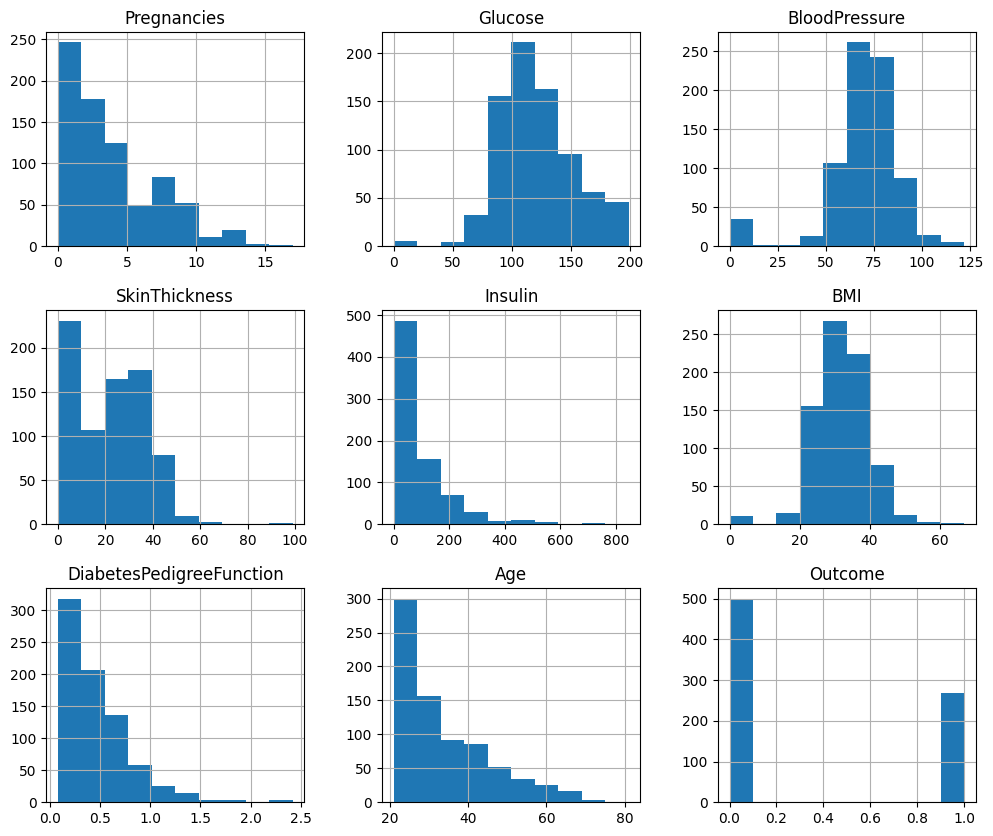

In [18]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.hist(figsize=(12,10))

plt.show()

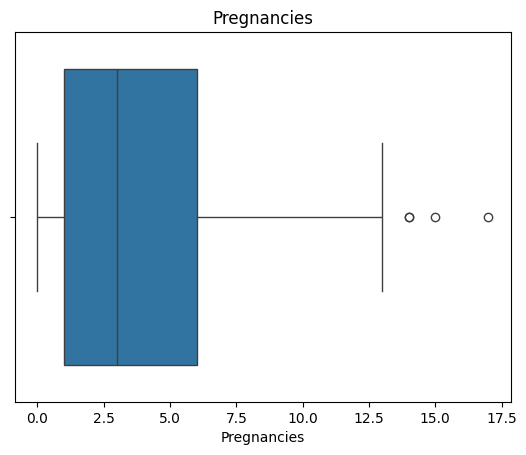

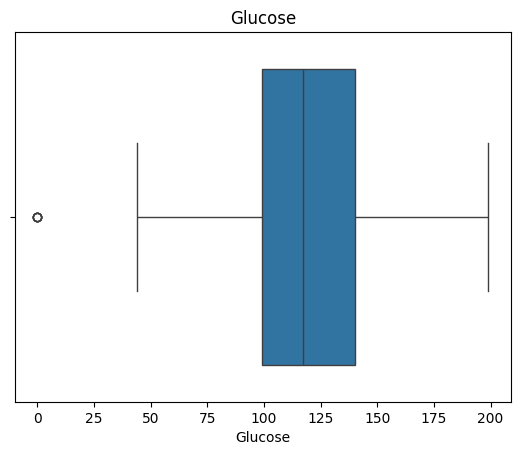

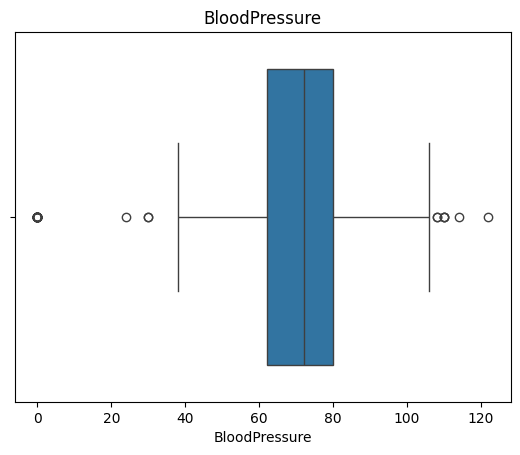

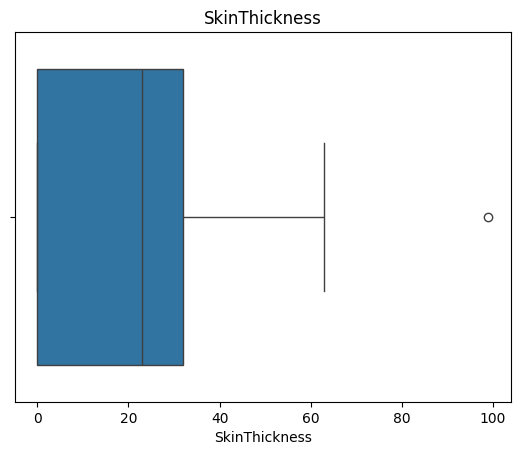

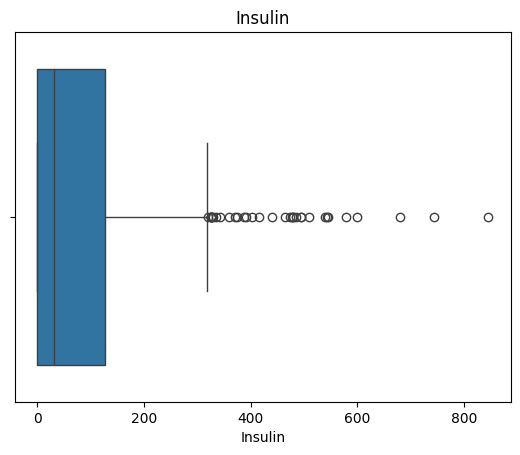

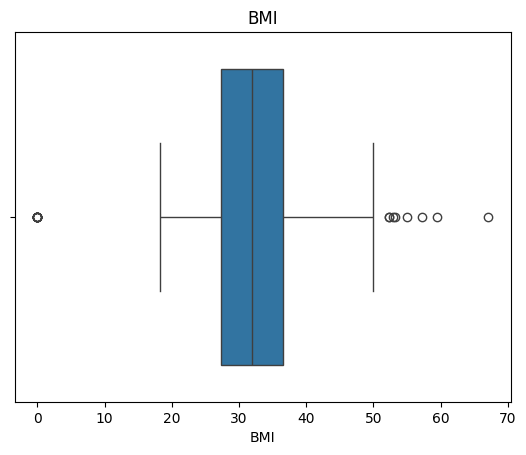

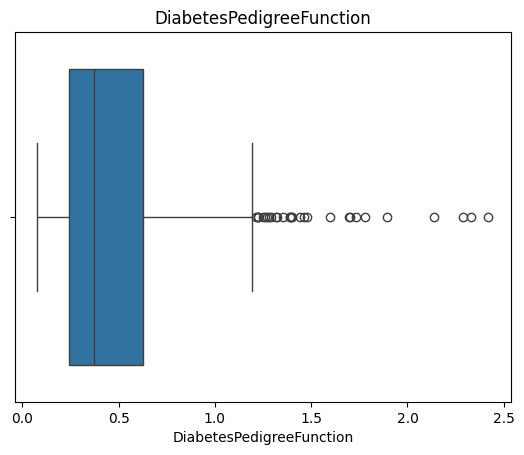

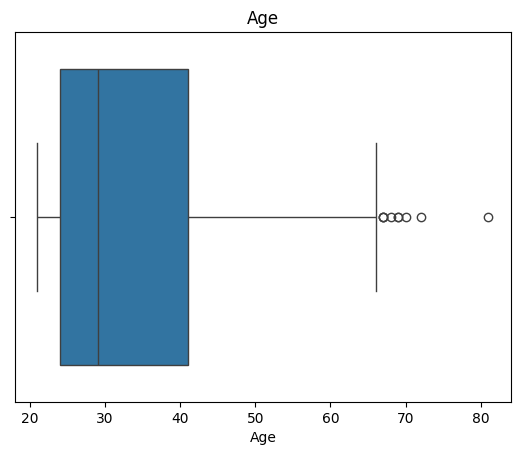

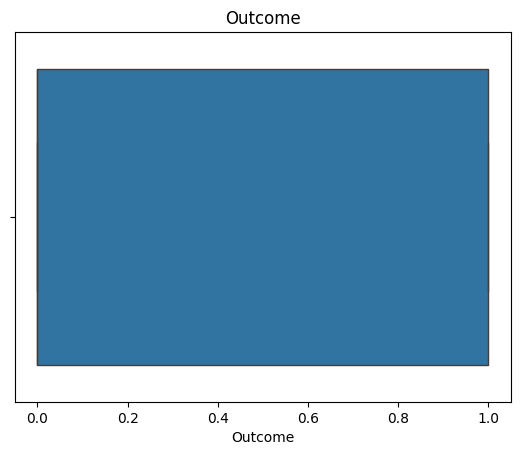

In [20]:
import seaborn as sns

for col in numeric_df.columns:

    plt.figure()

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

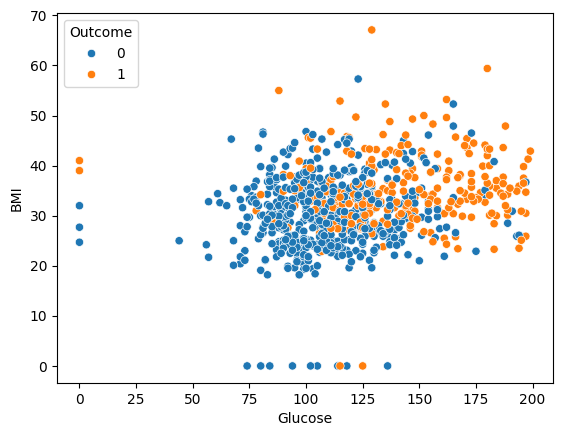

In [21]:
sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)

plt.show()

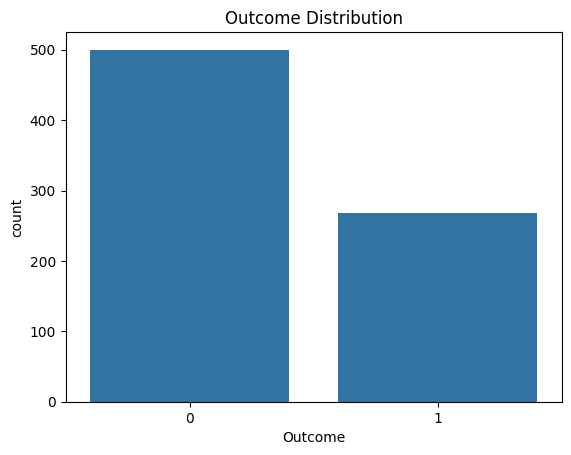

In [22]:
sns.countplot(
    x='Outcome',
    data=df
)

plt.title("Outcome Distribution")

plt.show()

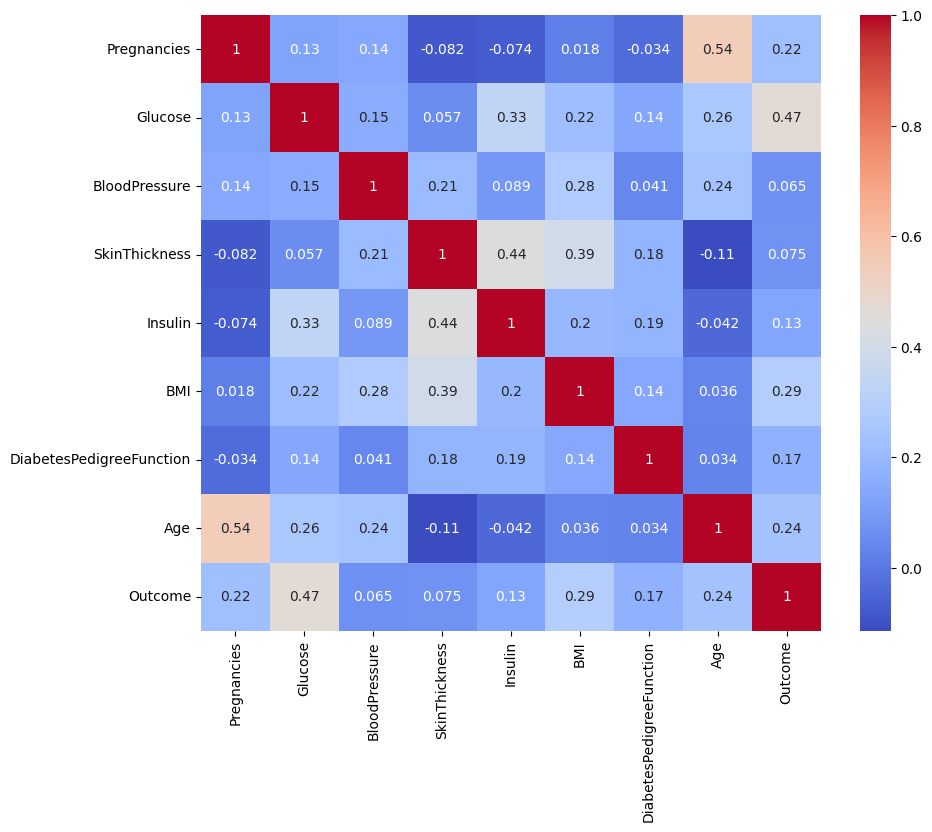

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Data Visualization

Histograms, boxplots, scatterplots, and heatmaps
help understand feature distributions and relationships.

In [24]:
df.fillna(
    df.mean(numeric_only=True),
    inplace=True
)

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:

    df[col] = le.fit_transform(df[col])

In [26]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Outcome', axis=1)

y = df['Outcome']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Data Preprocessing

Missing values were handled, categorical variables were encoded,
and feature scaling was applied to improve model performance.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.2,

    random_state=42
)

In [28]:
!pip install lightgbm xgboost

In [29]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier()

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier()

In [30]:
lgbm_pred = lgbm_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(
    "LightGBM Accuracy:",
    accuracy_score(y_test, lgbm_pred)
)

print(
    classification_report(
        y_test,
        lgbm_pred
    )
)

LightGBM Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        99
           1       0.57      0.65      0.61        55

    accuracy                           0.70       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.70      0.71       154



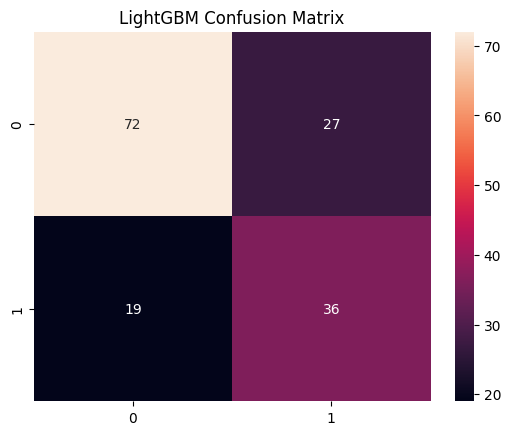

In [34]:
cm = confusion_matrix(y_test, lgbm_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("LightGBM Confusion Matrix")

plt.show()

In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [36]:
xgb_pred = xgb_model.predict(X_test)

In [37]:
print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

XGBoost Accuracy: 0.7207792207792207
              precision    recall  f1-score   support

           0       0.82      0.73      0.77        99
           1       0.59      0.71      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154



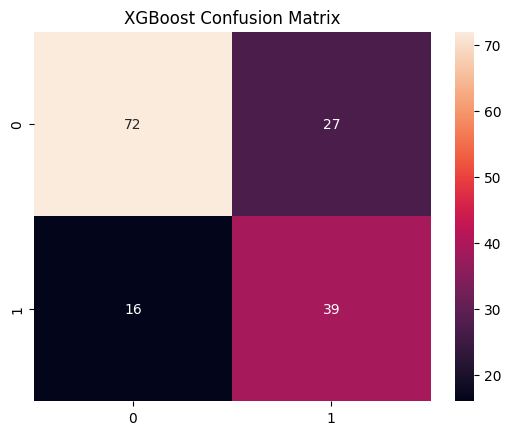

In [38]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("XGBoost Confusion Matrix")

plt.show()

In [39]:
lgbm_tuned = LGBMClassifier(

    learning_rate=0.05,

    n_estimators=200,

    max_depth=5
)

lgbm_tuned.fit(X_train, y_train)

lgbm_tuned_pred = lgbm_tuned.predict(X_test)

print(
    "Tuned LightGBM Accuracy:",
    accuracy_score(y_test, lgbm_tuned_pred)
)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [40]:
xgb_tuned = XGBClassifier(

    learning_rate=0.05,

    n_estimators=200,

    max_depth=5
)

xgb_tuned.fit(X_train, y_train)

xgb_tuned_pred = xgb_tuned.predict(X_test)

print(
    "Tuned XGBoost Accuracy:",
    accuracy_score(y_test, xgb_tuned_pred)
)

Tuned XGBoost Accuracy: 0.7077922077922078


In [41]:
print(
    "LightGBM Accuracy:",
    accuracy_score(y_test, lgbm_pred)
)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

print(
    "Tuned LightGBM Accuracy:",
    accuracy_score(y_test, lgbm_tuned_pred)
)

print(
    "Tuned XGBoost Accuracy:",
    accuracy_score(y_test, xgb_tuned_pred)
)

LightGBM Accuracy: 0.7012987012987013
XGBoost Accuracy: 0.7207792207792207
Tuned LightGBM Accuracy: 0.7272727272727273
Tuned XGBoost Accuracy: 0.7077922077922078


## Comparative Analysis

LightGBM and XGBoost were compared using:
- Accuracy
- Precision
- Recall
- F1-score

Hyperparameter tuning improved model performance.

Both algorithms are powerful boosting methods used for classification tasks.

# Conclusion

LightGBM and XGBoost models were successfully implemented
on the diabetes dataset.

EDA and preprocessing techniques improved data quality.

Both models were evaluated using accuracy, precision,
recall, F1-score, and confusion matrices.

Comparative analysis helped identify the better boosting
algorithm for diabetes prediction.